Universe of 500 assets across equities in the US only from 2013 with 3 year training period, 10 years of out sample backtesting data

- Markowitz model with risk aversion 2.5
- Covarinace LW linear shrinkage for covarinace estimation and historical mean return estimation with both 6 months lookback (Take covariance as solved)
- XGboost on OHLCV data with 24/36 months train period picked
- Added price and volume derivative indicators as features (good base results)
- Added alternative data like fundamental ratios as features (reduces performace on current small sample, not implemented here)
- Then constructed PCA components as features to train on (good and robust performance, 5 like FF5 in 2016)
- Added shrinkage and/or kalman filter (good results for estimation regularization and bias reduction)
- Added L2 regularization for variance reduction (reduces variance well in trade off for returns)
- Added Regime detection and regime based risk aversion + maybe regime training of prediction models (good results on drawdown reduction)

Test final vs basic historical return estimation Markowitz Shrunk Covariance method and 1/N benchmark
Test transaction costs included returns of active strategy vs passive strategy with initial buy and no rebalance and mounthly 1/N rebalancing with costs

[*********************100%***********************]  10 of 10 completed
[*********************100%***********************]  1 of 1 completed


Running backtest (no rebalancing messages)...

PERFORMANCE STATISTICS (Annualized)
                 Annual Return Annual Volatility Sharpe Ratio Max Drawdown Calmar Ratio Win Rate (daily) Average Monthly Return
Equal Weight            21.77%            19.64%       0.9024      -28.52%       0.7634           0.5470                  1.60%
Classic HRP             16.19%            15.92%       0.8182      -25.76%       0.6284           0.5513                  1.22%
VB-HRP Sharpe BL        19.30%            19.72%       0.7948      -29.91%       0.6452           0.5398                  1.42%


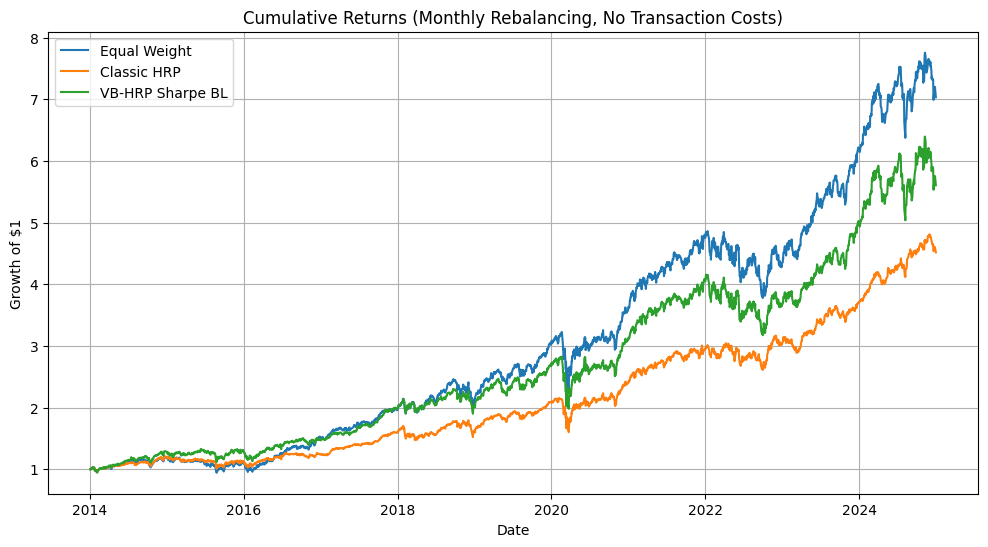

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
from scipy.cluster.hierarchy import linkage, leaves_list
import matplotlib.pyplot as plt
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# -------------------- Black‑Litterman helpers --------------------
from pypfopt.black_litterman import BlackLittermanModel
from pypfopt import black_litterman

def get_black_litterman_returns(prices, market_caps, market_prices, risk_free_rate=0.02):
    """
    Compute Black‑Litterman posterior expected annual returns.
    (No explicit views → posterior = market‑implied prior)
    """
    rets = prices.pct_change().dropna()
    cov = rets.cov() * 252
    delta = black_litterman.market_implied_risk_aversion(market_prices, risk_free_rate=risk_free_rate)
    pi = black_litterman.market_implied_prior_returns(market_caps, delta, cov, risk_free_rate=risk_free_rate)
    bl = BlackLittermanModel(cov, pi=pi, absolute_views={})
    return bl.bl_returns()

# -------------------- Volatility‑balanced clustering --------------------
class VolBalancedClusterer:
    def __init__(self, cov_matrix, brute_force_threshold=20):
        self.cov = cov_matrix.values
        self.assets = cov_matrix.index.tolist()
        self.n = len(self.assets)
        self.threshold = brute_force_threshold
        self.tree = None

    def _cluster_vol(self, indices):
        sub_cov = self.cov[np.ix_(indices, indices)]
        n = len(indices)
        if n == 0:
            return 0.0
        var = np.sum(sub_cov) / (n * n)
        return np.sqrt(var)

    def _best_split_bruteforce(self, indices):
        n = len(indices)
        if n <= 1:
            return None, None
        best_diff = np.inf
        best_pair = None
        for r in range(1, n // 2 + 1):
            for comb in combinations(indices, r):
                A = list(comb)
                B = [i for i in indices if i not in A]
                volA = self._cluster_vol(A)
                volB = self._cluster_vol(B)
                diff = abs(volA - volB)
                if diff < best_diff:
                    best_diff = diff
                    best_pair = (A, B)
        return best_pair

    def _best_split_heuristic(self, indices):
        vols = np.sqrt(np.diag(self.cov))
        sorted_idx = sorted(indices, key=lambda i: vols[i])
        n = len(sorted_idx)
        best_diff = np.inf
        best_pair = None
        for cut in range(1, n):
            left = sorted_idx[:cut]
            right = sorted_idx[cut:]
            volL = self._cluster_vol(left)
            volR = self._cluster_vol(right)
            diff = abs(volL - volR)
            if diff < best_diff:
                best_diff = diff
                best_pair = (left, right)
        return best_pair

    def _split(self, indices):
        if len(indices) <= 1:
            return None, None
        if len(indices) <= self.threshold:
            return self._best_split_bruteforce(indices)
        else:
            return self._best_split_heuristic(indices)

    def build_tree(self):
        root = {'indices': list(range(self.n))}
        queue = [root]
        while queue:
            node = queue.pop(0)
            idx = node['indices']
            if len(idx) <= 1:
                node['left'] = node['right'] = None
                continue
            left, right = self._split(idx)
            node['left'] = {'indices': left}
            node['right'] = {'indices': right}
            queue.append(node['left'])
            queue.append(node['right'])
        self.tree = root
        return self.tree

    def get_quasi_diag(self):
        if self.tree is None:
            self.build_tree()
        def _traverse(node):
            if node is None or node['indices'] is None:
                return []
            if len(node['indices']) == 1:
                return node['indices']
            return _traverse(node['left']) + _traverse(node['right'])
        return _traverse(self.tree)

# -------------------- HRP with Sharpe allocation + BL returns --------------------
class HRP_Sharpe_BL:
    def __init__(self, cov_matrix, expected_returns, risk_free_rate=0.02, brute_force_threshold=20):
        self.cov = cov_matrix.values
        self.assets = cov_matrix.index.tolist()
        self.n = len(self.assets)
        self.ret_series = expected_returns
        self.rf = risk_free_rate
        self.clusterer = VolBalancedClusterer(cov_matrix, brute_force_threshold)
        self.tree = None

    def _cluster_sharpe(self, indices):
        if len(indices) == 0:
            return 0.0
        returns = np.array([self.ret_series[self.assets[i]] for i in indices])
        mu = returns.mean()
        sub_cov = self.cov[np.ix_(indices, indices)]
        n = len(indices)
        sigma = np.sqrt(np.sum(sub_cov) / (n * n))
        if sigma < 1e-12:
            return 0.0
        return (mu - self.rf) / sigma

    def _recursive_bisection_sharpe(self, node, parent_weight):
        if node is None or len(node['indices']) == 0:
            return {}
        idx = node['indices']
        if len(idx) == 1:
            return {idx[0]: parent_weight}
        left = node['left']
        right = node['right']
        sharpeL = self._cluster_sharpe(left['indices'])
        sharpeR = self._cluster_sharpe(right['indices'])
        total = sharpeL + sharpeR
        alpha = sharpeL / total if total > 0 else 0.5
        left_weights = self._recursive_bisection_sharpe(left, parent_weight * alpha)
        right_weights = self._recursive_bisection_sharpe(right, parent_weight * (1 - alpha))
        return {**left_weights, **right_weights}

    def allocate(self):
        self.clusterer.build_tree()
        self.tree = self.clusterer.tree
        weights_dict = self._recursive_bisection_sharpe(self.tree, 1.0)
        weights = np.zeros(self.n)
        for i, w in weights_dict.items():
            weights[i] = w
        weights = weights / np.sum(weights)
        return pd.Series(weights, index=self.assets)

# -------------------- Classic HRP (inverse variance) --------------------
def classic_hrp(cov_matrix):
    corr = cov_matrix.corr()
    dist = np.sqrt(0.5 * (1 - corr))
    link = linkage(dist, method='single')
    order = leaves_list(link)
    cov_ordered = cov_matrix.iloc[order, order]
    def get_weights(cov_sub, indices):
        if len(indices) == 1:
            return {indices[0]: 1.0}
        mid = len(indices) // 2
        left = indices[:mid]
        right = indices[mid:]
        var_left = np.sum(cov_sub.loc[left, left].values) / (len(left)**2)
        var_right = np.sum(cov_sub.loc[right, right].values) / (len(right)**2)
        alpha = var_right / (var_left + var_right) if (var_left+var_right) > 0 else 0.5
        left_w = get_weights(cov_sub, left)
        right_w = get_weights(cov_sub, right)
        for k in left_w:
            left_w[k] *= alpha
        for k in right_w:
            right_w[k] *= (1-alpha)
        return {**left_w, **right_w}
    weights_dict = get_weights(cov_ordered, cov_ordered.index.tolist())
    weights = pd.Series(0.0, index=cov_matrix.index)
    for k, v in weights_dict.items():
        weights[k] = v
    return weights / weights.sum()

# -------------------- Performance statistics --------------------
def compute_performance_metrics(returns_series, risk_free_rate=0.02):
    """returns_series: daily returns (pandas Series)"""
    daily_rf = (1 + risk_free_rate) ** (1/252) - 1
    excess = returns_series - daily_rf
    ann_return = (1 + returns_series.mean()) ** 252 - 1
    ann_vol = returns_series.std() * np.sqrt(252)
    sharpe = excess.mean() / returns_series.std() * np.sqrt(252)
    cum = (1 + returns_series).cumprod()
    max_dd = (cum / cum.cummax() - 1).min()
    calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan
    win_rate = (returns_series > 0).mean()
    avg_monthly = returns_series.resample('ME').apply(lambda x: (1+x).prod() - 1).mean()
    return {
        'Annual Return': ann_return,
        'Annual Volatility': ann_vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_dd,
        'Calmar Ratio': calmar,
        'Win Rate (daily)': win_rate,
        'Average Monthly Return': avg_monthly
    }

# -------------------- Backtest (silent) --------------------
def backtest_strategies(prices, market_caps_series, market_prices, rebalance_freq=21,
                        risk_free_rate=0.02):
    returns = prices.pct_change().dropna()
    dates = returns.index
    rebal_dates = dates[::rebalance_freq]
    n_assets = len(prices.columns)

    # store daily returns for each strategy
    daily_returns = {
        'Equal Weight': pd.Series(dtype=float, index=dates),
        'Classic HRP': pd.Series(dtype=float, index=dates),
        'VB-HRP Sharpe BL': pd.Series(dtype=float, index=dates)
    }

    # initial equal weight for first period (before any rebalancing)
    current_weights = {
        'Equal Weight': pd.Series(1.0/n_assets, index=prices.columns),
        'Classic HRP': pd.Series(1.0/n_assets, index=prices.columns),
        'VB-HRP Sharpe BL': pd.Series(1.0/n_assets, index=prices.columns)
    }

    # iterate through rebalancing dates
    for i, date in enumerate(rebal_dates):
        idx = returns.index.get_loc(date)
        start = max(0, idx - 252)  # 1 year of daily data
        past_returns = returns.iloc[start:idx+1]
        if len(past_returns) < 10:
            # not enough data → keep equal weight
            pass
        else:
            cov = past_returns.cov() * 252
            # Black‑Litterman posterior returns
            try:
                bl_returns = get_black_litterman_returns(
                    prices.loc[past_returns.index],
                    market_caps_series,
                    market_prices.loc[past_returns.index],
                    risk_free_rate=risk_free_rate
                )
            except:
                bl_returns = pd.Series(0.0, index=prices.columns)

            # --- Classic HRP ---
            current_weights['Classic HRP'] = classic_hrp(cov)
            # --- VB‑HRP Sharpe BL ---
            try:
                hrp_sharpe = HRP_Sharpe_BL(cov, bl_returns, risk_free_rate)
                current_weights['VB-HRP Sharpe BL'] = hrp_sharpe.allocate()
            except:
                current_weights['VB-HRP Sharpe BL'] = pd.Series(1.0/n_assets, index=prices.columns)
            # Equal weight (unchanged)
            current_weights['Equal Weight'] = pd.Series(1.0/n_assets, index=prices.columns)

        # compute daily returns for the period until next rebalancing
        next_date = rebal_dates[i+1] if i+1 < len(rebal_dates) else dates[-1]
        period_dates = returns.loc[date:next_date].index
        for strat in daily_returns:
            w = current_weights[strat]
            strat_returns = (returns.loc[period_dates] * w).sum(axis=1)
            daily_returns[strat].loc[period_dates] = strat_returns

    # fill any NaN at the beginning (first few days before first rebalancing)
    for strat in daily_returns:
        daily_returns[strat].fillna(0, inplace=True)

    return daily_returns

# -------------------- Run and display results --------------------
if __name__ == "__main__":
    # Data download
     #['NVDA', 'GOOGL', 'AAPL', 'MSFT', 'AMZN', 'AVGO', 'META', 'TSLA', ]
    TICKERS = ['WMT', 'JPM', 'LLY', 'XOM', 'V', 'MU', 'AMD', 'JNJ', 'INTC', 'ORCL', ]
             ['MA', 'COST', 'NFLX', 'CVX', 'BAC', 'CAT', 'ABBV', 'CSCO', 'PG', 'KO', ]
             #'UNH', 'HD', 'LRCX', 'AMAT', 'GE', 'MS', 'MRK', 'GS', 'PM', 'WFC', 'TXN', 'KLAC', 'LIN', 'RTX', 'C', 'AXP']
    market_index = 'SPY'
    print("Downloading price data...")
    prices = yf.download(TICKERS, start='2014-01-01', end='2024-12-31')['Close']
    market_prices = yf.download(market_index, start='2018-01-01', end='2024-12-31')['Close']

    # Simplified market caps (replace with real data if available)
    mcap = pd.Series([1e11] * len(TICKERS), index=TICKERS)

    # Run silent backtest
    print("Running backtest (no rebalancing messages)...")
    daily_returns = backtest_strategies(prices, mcap, market_prices, rebalance_freq=21, risk_free_rate=0.00)

    # Compute performance metrics
    metrics = {}
    for strat, rets in daily_returns.items():
        metrics[strat] = compute_performance_metrics(rets)

    # Print formatted results
    print("\n" + "="*60)
    print("PERFORMANCE STATISTICS (Annualized)")
    print("="*60)
    df_metrics = pd.DataFrame(metrics).T
    # format as percentages or 4 decimals
    for col in ['Annual Return', 'Annual Volatility', 'Max Drawdown', 'Average Monthly Return']:
        df_metrics[col] = df_metrics[col].apply(lambda x: f"{x*100:.2f}%")
    for col in ['Sharpe Ratio', 'Calmar Ratio', 'Win Rate (daily)']:
        df_metrics[col] = df_metrics[col].apply(lambda x: f"{x:.4f}")
    print(df_metrics.to_string())

    # Plot cumulative returns
    plt.figure(figsize=(12,6))
    for strat, rets in daily_returns.items():
        cum = (1 + rets).cumprod()
        plt.plot(cum, label=strat)
    plt.title("Cumulative Returns (Monthly Rebalancing, No Transaction Costs)")
    plt.xlabel("Date")
    plt.ylabel("Growth of $1")
    plt.legend()
    plt.grid(True)
    plt.show()

## Libraries and configuration

In [ ]:
from __future__ import annotations

import sys
import warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')
from utils.plotting import *
from analysis.engine.backtest import *

# ===========================
# CONFIGURATION
# ===========================
BENCHMARK_TICKER = "SPY"
START_DATE = '2010-01-01'
END_DATE   = '2026-01-01'

PCA_features       = True               # enable PCA to substitute normal features
PCA_features_count = 5                  # factor features count

TRAIN_WINDOW_MONTHS    = 36             # rolling training window (months)
RISK_AVERSION          = 2.5              # lambda in mean-variance utility
REGIME_RISK_AVERSION_MULT = 2         # lamba multiplier in bear regimes
SHRINK_FACTOR          = 0.1           # weight on prior  (0 = raw XGB, 1 = prior)
PRIOR_TYPE             = 'cross_mean'   # 'cross_mean' | 'zero' | 'historical_mean'
TURNOVER_PENALTY       = 0.01           # per-unit L1 change from previous weights
L2_REG                 = 0.2           # L2 regularization (shrinks toward equal weight)
LOOKBACK_COV           = 6              # months for covariance estimation
RISK_FREE_RATE         = 0.04           # annualised risk-free rate
RETURN_SMOOTHING       = 'both'         # 'shrink', kalman' or 'both' - shrinkage first, then Kalman filter on the result
KALMAN_TRANSITION_COV  = 0.01           # process noise  (higher = faster adaptation)
KALMAN_OBSERVATION_COV = 0.05           # measurement noise (higher = more smoothing)


## Ticker collection

In [ ]:
# TICKERS = ['NVDA', 'GOOGL', 'AAPL', 'MSFT', 'AMZN', 'AVGO', 'META', 'TSLA', 
#               'WMT', 'JPM', 'LLY', 'XOM', 'V', 'MU', 'AMD', 'JNJ', 'INTC', 'ORCL', 
#               'MA', 'COST', 'NFLX', 'CVX', 'BAC', 'CAT', 'ABBV', 'CSCO', 'PG', 'KO', 
#               'UNH', 'HD', 'LRCX', 'AMAT', 'GE', 'MS', 'MRK', 'GS', 'PM', 'WFC', 'TXN', 'KLAC', 'LIN', 'RTX', 'C', 'AXP']

from concurrent.futures import ThreadPoolExecutor, as_completed

# ── Parameters ────────────────────────────────────────────────────────────────
MAX_TICKERS  = 100   # target universe size; set None to keep every valid ticker
MIN_COVERAGE = 0.95  # fraction of monthly periods that must have a price

# ── Load historical S&P 500 constituent snapshot at START_DATE ────────────────
# Uses the snapshot at START_DATE so there is no look-ahead bias.
_hist = pd.read_csv('./data/sp_500_historical_components.csv', parse_dates=['date'])
_snap = _hist[_hist['date'] >= START_DATE].iloc[0]
print(f"Constituent snapshot date : {_snap['date'].date()}")

_candidates = [t.strip().replace('.', '-') for t in _snap['tickers'].split(',')]
print(f"S&P 500 members at that date : {len(_candidates)} tickers")

# ── Download monthly close prices to assess data coverage ────────────────────
print(f"\nDownloading prices ({START_DATE} → {END_DATE}) to validate coverage ...")
_raw      = yf.download(_candidates, start=START_DATE, end=END_DATE,
                         auto_adjust=True, progress=True)['Close']
_monthly  = _raw.resample('ME').last()
_n_months = len(_monthly)

_coverage = _monthly.notna().sum() / _n_months
_valid    = _coverage[_coverage >= MIN_COVERAGE].index.tolist()
print(f"  {len(_valid)} tickers pass ≥{MIN_COVERAGE:.0%} monthly coverage filter")

# ── Fetch current market cap for every valid ticker (parallel) ────────────────
def _get_mcap(ticker):
    try:
        mc = yf.Ticker(ticker).fast_info.market_cap
        return ticker, mc if (mc and not np.isnan(mc)) else 0
    except Exception:
        return ticker, 0

print(f"\nFetching current market caps for {len(_valid)} tickers ...")
_mcaps = {}
with ThreadPoolExecutor(max_workers=20) as _pool:
    for _t, _mc in _pool.map(_get_mcap, _valid):
        _mcaps[_t] = _mc

_mcap_series = pd.Series(_mcaps).sort_values(ascending=False)
print(f"  Market caps retrieved (non-zero): {(_mcap_series > 0).sum()}")

# ── Select top MAX_TICKERS by market cap ──────────────────────────────────────
if MAX_TICKERS and len(_mcap_series) > MAX_TICKERS:
    _selected = sorted(_mcap_series.head(MAX_TICKERS).index.tolist())
    print(f"  Trimmed to top {MAX_TICKERS} by current market cap")
else:
    _selected = sorted(_mcap_series.index.tolist())

valid_tickers = _selected
print(f"\nFinal universe : {len(valid_tickers)} tickers")
print(valid_tickers)

$TWC: possibly delisted; no price data found  (1d 2010-01-01 -> 2026-01-01)
[                       0%                       ]

Constituent snapshot date : 2010-01-06
S&P 500 members at that date : 445 tickers



[                       1%                       ]  3 of 445 completed$ARG: possibly delisted; no price data found  (1d 2010-01-01 -> 2026-01-01)
$HRS: possibly delisted; no timezone found
[*                      3%                       ]  15 of 445 completed$AYE: possibly delisted; no price data found  (1d 2010-01-01 -> 2026-01-01)
[**                     4%                       ]  16 of 445 completed$NYX: possibly delisted; no price data found  (1d 2010-01-01 -> 2026-01-01)
[***                    6%                       ]  26 of 445 completed$MYL: possibly delisted; no timezone found
[***                    6%                       ]  27 of 445 completed$BRCM: possibly delisted; no price data found  (1d 2010-01-01 -> 2026-01-01)
[***                    7%                       ]  30 of 445 completed$CELG: possibly delisted; no timezone found
[***                    7%                       ]  31 of 445 completed$RRD: possibly delisted; no timezone found
[***                    7%

  327 tickers pass ≥95% monthly coverage filter

Fetching current market caps for 327 tickers ...


$SEE: possibly delisted; no price data found  (period=5d)
$TGNA: possibly delisted; no price data found  (period=5d)


  Market caps retrieved (non-zero): 326
  Trimmed to top 100 by current market cap

Final universe : 100 tickers
['AAPL', 'ABT', 'ADBE', 'ADI', 'AMAT', 'AMD', 'AMGN', 'AMZN', 'APH', 'AXP', 'BA', 'BAC', 'BK', 'BKNG', 'BMY', 'C', 'CAT', 'CB', 'CMCSA', 'CME', 'CMI', 'COF', 'COP', 'COST', 'CRM', 'CSCO', 'CVS', 'CVX', 'DE', 'DHR', 'DIS', 'DUK', 'ETN', 'FDX', 'GD', 'GE', 'GILD', 'GLW', 'GOOGL', 'GS', 'HD', 'HON', 'IBM', 'INTC', 'INTU', 'ISRG', 'JCI', 'JNJ', 'JPM', 'KLAC', 'KO', 'LLY', 'LMT', 'LOW', 'MA', 'MAR', 'MCD', 'MCK', 'MDT', 'MO', 'MRK', 'MS', 'MSFT', 'MU', 'NEE', 'NEM', 'NVDA', 'ORCL', 'PEP', 'PFE', 'PG', 'PGR', 'PH', 'PLD', 'PM', 'PNC', 'PWR', 'QCOM', 'SBUX', 'SCHW', 'SO', 'SPGI', 'SYK', 'T', 'TJX', 'TMO', 'TMUS', 'TXN', 'UNH', 'UNP', 'UPS', 'V', 'VZ', 'WDC', 'WELL', 'WFC', 'WM', 'WMB', 'WMT', 'XOM']


## Backtesting module


In [ ]:
import analysis.engine.backtest as bt
# Push notebook constants into the module so every function reads the values you
# set above, even when they are called without explicit keyword arguments.
bt.RISK_AVERSION             = RISK_AVERSION
bt.REGIME_RISK_AVERSION_MULT = REGIME_RISK_AVERSION_MULT
bt.TURNOVER_PENALTY          = TURNOVER_PENALTY
bt.L2_REG                    = L2_REG
bt.LOOKBACK_COV              = LOOKBACK_COV
bt.RISK_FREE_RATE            = RISK_FREE_RATE
bt.SHRINK_FACTOR             = SHRINK_FACTOR
bt.PRIOR_TYPE                = PRIOR_TYPE
bt.RETURN_SMOOTHING          = RETURN_SMOOTHING
bt.KALMAN_TRANSITION_COV     = KALMAN_TRANSITION_COV
bt.KALMAN_OBSERVATION_COV    = KALMAN_OBSERVATION_COV


## Run Pipeline

In [ ]:
print("Fitting SPY regime model ...")
spy_labels = get_spy_regime_labels(start=START_DATE, train_duration=TRAIN_WINDOW_MONTHS)
print(f"Regime coverage: {spy_labels.value_counts().to_dict()}")

In [ ]:
print("Fetching data and engineering features...")
features = fetch_and_engineer_features(valid_tickers, START_DATE, END_DATE)
print(f"Feature set shape: {features.shape}")

print("Computing walk-forward XGBoost forecasts...")
forecasts = get_monthly_forecasts(features, TRAIN_WINDOW_MONTHS, PCA_added=PCA_features, PCA_count=PCA_features_count)

if forecasts.empty:
    print("No forecasts generated. Check data availability.")
    port_ret, bench_ret, weights_df, monthly_returns = None, None, None, None
else:
    print(f"Processing return forecasts (mode='{RETURN_SMOOTHING}')...")
    shrunk = process_forecasts(forecasts, mode=RETURN_SMOOTHING, prior_type=PRIOR_TYPE, shrink_factor=SHRINK_FACTOR)

    monthly_returns = features['ret_1m'].unstack().dropna(axis=1, how='all')
    monthly_returns = monthly_returns.loc[monthly_returns.index >= shrunk.index.get_level_values(0).min()]

    print("Computing shrunk covariance matrices...")
    cov_dict = get_shrunk_covariance(monthly_returns, LOOKBACK_COV)

    print("Running backtest against 1/n benchmark...")
    port_ret, bench_ret, weights_df = run_backtest_with_benchmark(
        monthly_returns, shrunk, cov_dict, spy_labels=spy_labels
    )

    if len(port_ret) == 0:
        print("No portfolio returns generated.")
        port_ret, bench_ret, weights_df, monthly_returns = None, None, None, None
    else:
        metrics_port  = compute_metrics(port_ret,  "Active Portfolio")
        metrics_bench = compute_metrics(bench_ret, "1/n Equal Weight")

        print("\n" + "="*50)
        print("COMPARISON RESULTS (Monthly Rebalancing)")
        print("="*50)
        for m in [metrics_port, metrics_bench]:
            name = list(m.keys())[0]
            d    = m[name]
            print(f"\n{name}:")
            print(f"  Ann. Return:        {d['Ann. Return (%)']:.2f}%")
            print(f"  Cumul. Return:      {d['Cumul. Return (%)']:.2f}%")
            print(f"  Ann. Volatility:    {d['Ann. Volatility (%)']:.2f}%")
            print(f"  Sharpe Ratio:       {d['Sharpe Ratio']:.3f}")
            print(f"  Sortino Ratio:      {d['Sortino Ratio']:.3f}")
            print(f"  Calmar Ratio:       {d['Calmar Ratio']:.3f}")
            print(f"  Max Drawdown:       {d['Max Drawdown (%)']:.2f}%")
            print(f"  VaR 95%:            {d['VaR 95% (%)']:.2f}%")
            print(f"  CVaR 95%:           {d['CVaR 95% (%)']:.2f}%")
            print(f"  Hit Rate:           {d['Hit Rate (%)']:.1f}%")
            print(f"  Win/Loss Ratio:     {d['Win/Loss Ratio']:.3f}")

## SPY Benchmark

In [ ]:
# Download SPY from Yahoo Finance and align to the backtest period.
spy_raw = yf.download(BENCHMARK_TICKER, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)
spy_close = spy_raw['Close']
if isinstance(spy_close, pd.DataFrame):
    spy_close = spy_close.squeeze()
spy_monthly = spy_close.resample('ME').last()
spy_ret = spy_monthly.pct_change().dropna()
spy_ret.name = 'SPY'

# Align all three series to a common date range.
all_dates = port_ret.index.intersection(bench_ret.index).intersection(spy_ret.index)
returns_df = pd.DataFrame({
    'Active Strategy': port_ret,
    '1/n Equal Weight':  bench_ret,
    'SPY':               spy_ret,
}).loc[all_dates].dropna()

print(f'Aligned period : {all_dates[0].date()} to {all_dates[-1].date()}')
print(f'Monthly periods: {len(returns_df)}')
returns_df.tail()

## Performance Visualisations

### Cumulative Returns

In [ ]:
plot_cumulative_returns(
    returns_df,
    title='Cumulative Returns: Active Strategy vs. Benchmarks',
)

### Drawdown

In [ ]:
plot_drawdown(
    returns_df,
    title='Drawdown: Active Strategy vs. Benchmarks',
)

### Rolling Sharpe Ratio

In [ ]:
plot_rolling_sharpe(
    returns_df,
    window=12,
    title='Rolling Sharpe Ratio (12-month window)',
)

### Rolling Volatility

In [ ]:
plot_rolling_volatility(
    returns_df,
    window=12,
    title='Rolling Volatility (12-month window)',
)

### Sharpe Ratio Comparison

In [ ]:
monthly_rf = RISK_FREE_RATE / 12
sharpe_series = pd.Series(
    {
        col: (returns_df[col].mean() - monthly_rf) / returns_df[col].std() * np.sqrt(12)
        for col in returns_df.columns
    },
    name='Annualised Sharpe',
)
plot_sharpe_bar(sharpe_series, title='Annualised Sharpe Ratio by Strategy')

### Performance Summary

In [ ]:
spy_benchmark = returns_df['SPY']

all_metrics = {}
for col in returns_df.columns:
    bench = spy_benchmark if col != 'SPY' else None
    m = compute_metrics(returns_df[col], col, benchmark_series=bench)
    all_metrics.update(m)

metrics_df = pd.DataFrame(all_metrics).T

# ── Compact summary bar-chart (4 key metrics) ─────────────────────────────────
stats_df = metrics_df[['Ann. Return (%)', 'Ann. Volatility (%)', 'Sharpe Ratio', 'Max Drawdown (%)']].copy()
stats_df.columns = ['Ann. Return (%)', 'Ann. Vol (%)', 'Sharpe Ratio', 'Max Drawdown (%)']
plot_performance_summary(stats_df)

# ── Comprehensive metrics table ────────────────────────────────────────────────
plot_metrics_table(metrics_df, title="Comprehensive Performance Metrics")

# ── Printed table ─────────────────────────────────────────────────────────────
display(metrics_df.round(3))

### Portfolio Weights Heatmap

In [ ]:
plot_weights_heatmap(
    weights_df,
    title='Active Strategy Portfolio Weights Over Time',
)

### Portfolio Weight Allocation (Stacked Area)

In [ ]:
plot_weights_area(
    weights_df,
    title='Active Strategy Weight Allocation Over Time',
    top_n=15,
)

### Annual Returns

In [ ]:
plot_annual_returns(
    returns_df,
    title='Annual Returns by Strategy',
)

### Monthly Returns Calendar Heatmap

In [ ]:
for col in returns_df.columns:
    plot_monthly_returns_heatmap(
        returns_df[col],
        title=f'Monthly Returns — {col}',
    )

### Return Distributions

In [ ]:
plot_return_distribution(
    returns_df,
    title='Return Distributions: All Strategies',
)

### Risk-Return Profile

In [ ]:
plot_risk_return_scatter(
    returns_df,
    risk_free_rate=RISK_FREE_RATE,
    title='Risk-Return Profile',
)

### Rolling Beta vs SPY

In [ ]:
plot_rolling_beta(
    returns_df,
    benchmark_col='SPY',
    window=12,
    title='Rolling Beta vs SPY (12-month window)',
)

## Transaction Cost & Slippage Analysis

In [ ]:
import matplotlib.ticker as mtick

# ── Configurable inputs ───────────────────────────────────────────────────────
SLIPPAGE_BPS = 50    # one-way slippage in basis points  (5 bps = 0.05 %)
TC_BPS       = 100   # one-way commission / bid-ask cost (10 bps = 0.10 %)

# ── Reconstruct equal-weight bench weights (same universe as active) ──────────
def _bench_weights(active_wts):
    """1/N weights across the same non-zero tickers the active strategy holds."""
    in_universe = (active_wts > 0)
    n           = in_universe.sum(axis=1)
    return in_universe.div(n, axis=0).fillna(0).astype(float)

bench_weights_df = _bench_weights(weights_df)

# ── Apply costs ───────────────────────────────────────────────────────────────
net_active, to_active = bt.apply_transaction_costs(port_ret,  weights_df,      TC_BPS, SLIPPAGE_BPS)
net_bench,  to_bench  = bt.apply_transaction_costs(bench_ret, bench_weights_df, TC_BPS, SLIPPAGE_BPS)

common_dates    = returns_df.index
returns_cost_df = pd.DataFrame({
    'Active (Gross)': port_ret,
    'Active (Net)'  : net_active,
    '1/n (Gross)'   : bench_ret,
    '1/n (Net)'     : net_bench,
    'SPY'           : spy_ret,
}).reindex(common_dates).dropna()

# ── Summary statistics ────────────────────────────────────────────────────────
total_bps      = TC_BPS + SLIPPAGE_BPS
drag_active    = (to_active * total_bps / 10_000).reindex(common_dates).dropna()
drag_bench     = (to_bench  * total_bps / 10_000).reindex(common_dates).dropna()

print(f"Cost assumption : TC = {TC_BPS} bps  |  Slippage = {SLIPPAGE_BPS} bps  "
      f"(total {total_bps} bps one-way per unit turnover)")
print(f"Avg monthly turnover  — Active : {to_active.mean():.1%}   1/n : {to_bench.mean():.1%}")
print(f"Avg monthly cost drag — Active : {drag_active.mean():.3%}  1/n : {drag_bench.mean():.3%}")
print(f"Annualised cost drag  — Active : {drag_active.mean()*12:.2%}  1/n : {drag_bench.mean()*12:.2%}")

# ── Metrics table ─────────────────────────────────────────────────────────────
spy_ref  = returns_cost_df['SPY']
all_met  = {}
for col in returns_cost_df.columns:
    bench_ref = spy_ref if col != 'SPY' else None
    all_met.update(compute_metrics(returns_cost_df[col], col, benchmark_series=bench_ref))

metrics_cost_df = pd.DataFrame(all_met).T
plot_metrics_table(metrics_cost_df, title=f"Performance — Gross vs Net of Costs  (TC={TC_BPS} bps, Slip={SLIPPAGE_BPS} bps)")
display(metrics_cost_df[['Ann. Return (%)', 'Ann. Volatility (%)', 'Sharpe Ratio',
                          'Max Drawdown (%)', 'Calmar Ratio']].round(3))

# ── Plot 1: Cumulative returns ────────────────────────────────────────────────
plot_cumulative_returns(
    returns_cost_df,
    title=f'Cumulative Returns — Gross vs Net  (TC={TC_BPS} bps, Slip={SLIPPAGE_BPS} bps)',
)

# ── Plot 2: Drawdown ──────────────────────────────────────────────────────────
plot_drawdown(
    returns_cost_df,
    title='Drawdown — Gross vs Net of Costs',
)

# ── Plot 3: Monthly turnover ──────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
ax1.bar(to_active.reindex(common_dates).index,
        to_active.reindex(common_dates).values * 100,
        width=20, color='#2196F3', alpha=0.75, label='Active')
ax1.set_ylabel('One-Way Turnover (%)')
ax1.set_title('Monthly Portfolio Turnover')
ax1.legend()

ax2.bar(to_bench.reindex(common_dates).index,
        to_bench.reindex(common_dates).values * 100,
        width=20, color='#4CAF50', alpha=0.75, label='1/n Bench')
ax2.set_ylabel('One-Way Turnover (%)')
ax2.legend()
fig.tight_layout()
plt.show()

# ── Plot 4: Annualised cost drag over time ────────────────────────────────────
cost_ts_active = (port_ret - net_active).reindex(common_dates) * 12 * 100
cost_ts_bench  = (bench_ret - net_bench).reindex(common_dates) * 12 * 100

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(cost_ts_active.dropna().index, cost_ts_active.dropna().values,
                alpha=0.55, color='#2196F3', label='Active')
ax.fill_between(cost_ts_bench.dropna().index,  cost_ts_bench.dropna().values,
                alpha=0.55, color='#4CAF50', label='1/n Bench')
ax.set_title('Annualised Cost Drag Over Time (% p.a.)')
ax.set_ylabel('Cost Drag (% p.a.)')
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f%%'))
ax.legend()
fig.tight_layout()
plt.show()

# ── Plot 5: Cost sensitivity sweep ───────────────────────────────────────────
cost_grid = [0, 5, 10, 20, 30, 50, 75, 100]   # total one-way bps
rows = []
for tbps in cost_grid:
    tc_s, sl_s = tbps // 2, tbps - tbps // 2
    na, _ = bt.apply_transaction_costs(port_ret,  weights_df,      tc_bps=tc_s, slippage_bps=sl_s)
    nb, _ = bt.apply_transaction_costs(bench_ret, bench_weights_df, tc_bps=tc_s, slippage_bps=sl_s)
    na = na.reindex(common_dates).dropna()
    nb = nb.reindex(common_dates).dropna()
    mrf = RISK_FREE_RATE / 12
    rows.append({
        'Total Cost (bps)'     : tbps,
        'Active Sharpe'        : (na.mean() - mrf) / na.std() * np.sqrt(12),
        '1/n Sharpe'           : (nb.mean() - mrf) / nb.std() * np.sqrt(12),
        'Active Ann. Return (%)': na.mean() * 12 * 100,
        '1/n Ann. Return (%)'  : nb.mean() * 12 * 100,
    })

sweep_df = pd.DataFrame(rows).set_index('Total Cost (bps)')

fig, (ax_s, ax_r) = plt.subplots(1, 2, figsize=(14, 5))

ax_s.plot(sweep_df.index, sweep_df['Active Sharpe'], 'o-',  color='#2196F3', label='Active')
ax_s.plot(sweep_df.index, sweep_df['1/n Sharpe'],   's--', color='#4CAF50', label='1/n Bench')
ax_s.axhline(0, color='grey', lw=0.8, ls=':')
ax_s.set_title('Sharpe Ratio vs. Total Cost')
ax_s.set_xlabel('Total One-Way Cost (bps)')
ax_s.set_ylabel('Annualised Sharpe Ratio')
ax_s.legend()

ax_r.plot(sweep_df.index, sweep_df['Active Ann. Return (%)'], 'o-',  color='#2196F3', label='Active')
ax_r.plot(sweep_df.index, sweep_df['1/n Ann. Return (%)'],   's--', color='#4CAF50', label='1/n Bench')
ax_r.set_title('Ann. Return vs. Total Cost')
ax_r.set_xlabel('Total One-Way Cost (bps)')
ax_r.set_ylabel('Annualised Return (%)')
ax_r.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f%%'))
ax_r.legend()

fig.suptitle('Cost Sensitivity Analysis', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

print("\nCost Sensitivity Table:")
display(sweep_df.round(3))